In [1]:
import ee 
from RadGEEToolbox import GenericCollection, LandsatCollection, get_palette
# import GEE_UBM
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [2]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

#### Local helpers and static variables

In [3]:
def convert_depth_to_volume(image):
    """
    Converts pixel values from depth (mm) to volume (cubic meters).
    
    Formula: Area (m^2) * Depth (mm) / 1000 (mm/m) = Volume (m^3)
    """
    # 1. Calculate area of each pixel in square meters
    pixel_area = ee.Image.pixelArea()
    
    # 2. Convert depth to meters (mm / 1000)
    depth_in_meters = image.multiply(0.001)
    
    # 3. Calculate volume
    volume_m3 = pixel_area.multiply(depth_in_meters)
    
    return volume_m3.copyProperties(image, image.propertyNames())

GSL_basin = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Watersheds/Merged_GSL_Basin_Watershed").geometry()

#### Defining the UBM inputs collection and exporting to a GEE asset (optional but more efficient and redudant)

> This cell only needs to be ran when you are looking to export a new asset to GEE for a new input collection or model run

Change `run_loop` to `True` if you want to export the image collection to an asset.

We define each input band/raster, then combine all the individual bands/rasters using `build_model_ready_collection()` which acts as the input for the UBM model

To maximize efficiency and store the input collections for later usage, we export the collection to an asset using `export_to_asset_collection`

In [4]:
### Defining the UBM input collection for the Modified UBM 1 (OpenET as input) and exporting the collection as an asset to boost model run times later.
run_loop = False
if run_loop:
    years = np.arange(2015, 2025, 1)
    for year in years:
        base_class = InputCollections(start_date=f'{year}-01-01', end_date=f'{year}-12-31', soil_thickness_raster='gNATSGO_filled')
        soil_thickness_raster = base_class.soil_thickness_raster
        porosity = base_class.get_static_raster('HiHydroSoilPorosity') #HiHydroSoil porosity is lower than POLARIS and more reasonable
        field_capacity = base_class.get_static_raster('OpenLandMapFieldCap') #'UGS_fieldCap - OLM FC looks better to me
        wilting_point = base_class.get_static_raster('HiHydroSoilWiltPoint') #'UGS_wiltingPoint - HiHydroSoil WP looks better to me
        Geo_K = base_class.get_static_raster('UGS_Geo_K')
        snowmelt_and_precip = base_class.get_precip_and_snowmelt('DAYMET_SNODAS_combined_inputs_monthly')
        AET = base_class.get_AET('OPEN_ET_EEMETRIC') 
        model_ready_collection = build_model_ready_collection(timeseries_collections_list=[snowmelt_and_precip, AET], static_images_list=[soil_thickness_raster, porosity, field_capacity, wilting_point, Geo_K])
        dates = model_ready_collection.dates
        scale = model_ready_collection.image_grab(0).select('soil_porosity').projection().nominalScale().getInfo()
        export = model_ready_collection.export_to_asset_collection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M', 
                                                        region=base_class.Utah_Regional_Boundary.geometry(), scale=scale)

#### Importing the collection exported from the previous cell to use as an input for the UBM model
We import the GEE asset as an image collection, cast it to a GenericCollection object, then insert that object as the input collection for the `ModifiedUBM1Run` which runs the UBM. We then convert the mm water depth pixel values to volume pixels by mapping `convert_depth_to_volume` over the processed UBM image collection.

> The output bands of the UBM (modified 1) are: 1) Runoff, 2) Recharge, and 3) Water in the Soil (Soil_Water_End_Of_Previous_Timestep)

In [5]:
model_ready_collection_asset = ee.ImageCollection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M')
model_ready_collection_asset = GenericCollection(model_ready_collection_asset)
print(model_ready_collection_asset.dates)
print(len(model_ready_collection_asset.dates))
print(model_ready_collection_asset.image_grab(0).bandNames().getInfo())
UBM_M1_col = ModifiedUBM1Run(model_ready_collection_asset)
dates = UBM_M1_col.dates
print(dates)


UBM_M1_volume_col = GenericCollection(collection=UBM_M1_col.collection.map(convert_depth_to_volume), 
                                      start_date='2016-01-01', end_date='2024-12-31')

['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01', '2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020

#### Zonal statistics on the UBM model to create time-series of soil water balance model outputs (including AET from the input collection for comparisons)

In [6]:
GSL_basin_recharge = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Recharge', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
GSL_basin_runoff = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Runoff', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
GSL_basin_soil_water = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Soil_Water_End_Of_Previous_Timestep', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])

model_inputs_as_volume = GenericCollection(collection=model_ready_collection_asset.collection.map(convert_depth_to_volume), start_date='2015-01-01', end_date='2024-12-31')
GSL_basin_AET = model_inputs_as_volume.iterate_zonal_stats(geometries=GSL_basin, band='AET', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
GSL_basin_precip_and_snowmelt = model_inputs_as_volume.iterate_zonal_stats(geometries=GSL_basin, band='precip_and_snowmelt_input', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])

model_input_stats = pd.concat([GSL_basin_precip_and_snowmelt, GSL_basin_AET['GSL Basin_sum']], axis=1)
model_input_stats = model_input_stats[model_input_stats['Date'] > '2015-12-31']
model_input_stats.columns = ['Date', 'Precip_and_Snowmelt_m3', 'AET_m3']
model_input_stats['Date'] = pd.to_datetime(model_input_stats['Date'])
model_input_stats = model_input_stats.reset_index(drop=True)

zonal_stats_df = pd.concat([GSL_basin_recharge, GSL_basin_runoff['GSL Basin_sum'], GSL_basin_soil_water['GSL Basin_sum']], axis=1)
zonal_stats_df.columns = ['Date', 'Recharge_m3', 'Runoff_m3', 'Soil_Water_End_m3']
zonal_stats_df['Date'] = pd.to_datetime(zonal_stats_df['Date'])
zonal_stats_df = pd.concat([zonal_stats_df, model_input_stats[['Precip_and_Snowmelt_m3', 'AET_m3']]], axis=1)
print(zonal_stats_df)

          Date   Recharge_m3     Runoff_m3  Soil_Water_End_m3  \
0   2016-01-01  1.826006e+09  6.503045e+08       7.402733e+09   
1   2016-02-01  6.438224e+08  1.731898e+08       7.355315e+09   
2   2016-03-01  1.410970e+09  6.152405e+08       7.314664e+09   
3   2016-04-01  8.563665e+08  2.280043e+08       7.194238e+09   
4   2016-05-01  3.671089e+08  5.156677e+07       6.975461e+09   
..         ...           ...           ...                ...   
103 2024-08-01  1.009479e+08  2.370561e+06       4.384907e+09   
104 2024-09-01  4.914061e+07  2.920242e+05       4.169433e+09   
105 2024-10-01  7.791113e+07  1.146264e+06       4.269148e+09   
106 2024-11-01  2.033561e+08  7.341233e+06       4.889922e+09   
107 2024-12-01  6.514771e+08  7.122338e+07       5.622474e+09   

     Precip_and_Snowmelt_m3        AET_m3  
0              3.447997e+09  1.233421e+08  
1              1.058954e+09  2.256506e+08  
2              2.951607e+09  8.644242e+08  
3              2.184977e+09  1.355102e+09  

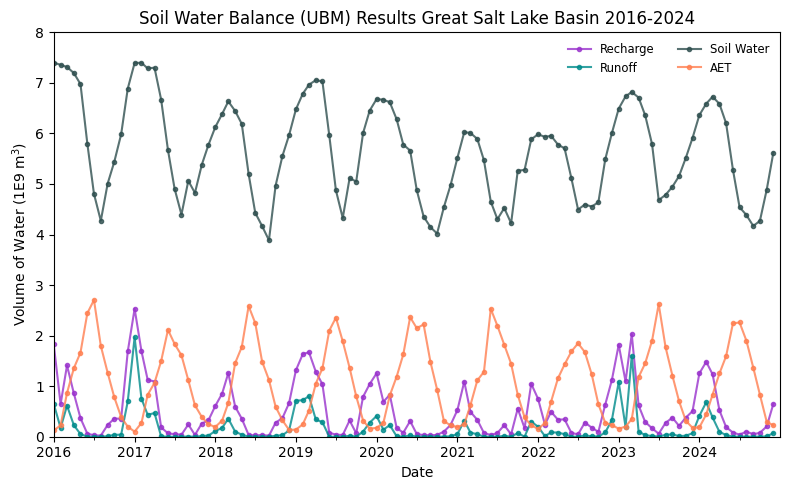

In [9]:
GSL_basin_recharge['Date'] = pd.to_datetime(GSL_basin_recharge['Date'])
GSL_basin_AET['Date'] = pd.to_datetime(GSL_basin_AET['Date'])
markersize = 3
alpha = 0.8
plt.figure(figsize=(8,5))
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Recharge_m3'], marker='o', color='darkorchid', markersize=markersize, alpha=alpha, label='Recharge')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='Runoff')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Soil Water')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='coral', markersize=markersize, alpha=alpha, label='AET')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2024-12-31'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(7))
plt.gca().yaxis.get_offset_text().set_visible(False)
plt.ylim(0, 8E9)
plt.title('Soil Water Balance (UBM) Results Great Salt Lake Basin 2016-2024')
plt.xlabel('Date')
plt.ylabel('Volume of Water (1E9 m$^3$)')
plt.legend(loc='upper right', fontsize='small', frameon=False, ncol=2)
plt.tight_layout()
plt.show()

#### Mapping the results of the UBM collection

> Change the index value to cycle through images in the UBM collection. The date of the selected image will print above the map when the cell is run. Comment out the lower block of `Map.addLayer()` calls to explore the inputs to the model

In [7]:
index = 13
image = UBM_M1_col.image_grab(index)

Map = geemap.Map(center=[39.5, -111.5], zoom=7)

### UBM Outputs ###
Map.addLayer(image, vis_params={'bands':['Runoff'], 'min':0, 'max':300, 'palette':get_palette('inferno')}, name='Runoff') #rdylbu
Map.addLayer(image, vis_params={'bands':['Recharge'], 'min':0, 'max':300, 'palette':get_palette('inferno')}, name='Recharge')
Map.addLayer(image, vis_params={'bands':['Soil_Water_End_Of_Previous_Timestep'], 'min':0, 'max':500, 'palette':get_palette('rdylbu')}, name='Soil_Water_End_of_Timestep')

### UBM Inputs ###
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['precipitation'], 'min':0, 'max':100, 'palette':get_palette('blues')}, name='Precipitation')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['snowmelt'], 'min':0, 'max':50, 'palette':get_palette('blues')}, name='snowmelt')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_thickness'], 'min':0, 'max':2500, 'palette':get_palette('viridis')}, name='soil_thickness')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_thickness'], 'min':0, 'max':14000, 'palette':get_palette('viridis')}, name='soil_thickness')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['field_capacity'], 'min':0, 'max':500, 'palette':get_palette('viridis')}, name='field_capacity')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['wilting_point'], 'min':0, 'max':500, 'palette':get_palette('viridis')}, name='wilting_point')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['Geo_K'], 'min':0, 'max':10000, 'palette':get_palette('viridis')}, name='Geo_K')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_porosity'], 'min':0, 'max':0.5, 'palette':get_palette('viridis')}, name='soil_porosity')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['PET'], 'min':0, 'max':500, 'palette':get_palette('oranges')}, name='PET')
print(dates[index])
Map

2016-02-01


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…